In [1]:
from pymodulon.core import IcaData
from pymodulon.plotting import *
from os import path
import pandas as pd
import re
from Bio.KEGG import REST
from tqdm.notebook import tqdm
from pymodulon.io import *
from pymodulon.compare import *
from datetime import datetime, timedelta
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu, median_abs_deviation, pearsonr, skew
from sklearn.decomposition import PCA
import numpy as np
from sklearn.preprocessing import StandardScaler
import pylab



pd.set_option('display.max_columns', 100, 'display.max_rows', 100)

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_style('ticks')
matplotlib.rcParams['text.color'] = '#000000'
matplotlib.rcParams['axes.labelcolor'] = '#000000'
matplotlib.rcParams['xtick.color'] = '#000000'
matplotlib.rcParams['ytick.color'] = '#000000'

In [3]:
ica_data = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\PRECISE_WT_MG1655_final2.json.gz')

## Figure 1A

In [4]:
# PRECISE - all
data1 = pd.read_csv('C:\\Users\\99hee\\precise_mg1655_R1\\data\\precise-1-k-files\\PRECISE_data\\Dataset1.csv').set_index('Unnamed: 0')
# PRECISE-1K - all
data2 = pd.read_csv('C:\\Users\\99hee\\precise_mg1655_R1\\data\\precise-1-k-files\\PRECISE_data\\Dataset2.csv').set_index('sample_id')

# WT samples only, sorted by run date
# PRECISE
precise_metadata_sorted = data1.loc[list(set(data1.index.values).intersection(ica_data.sample_table.sample_id.values))].sort_values('run_date')
#PRECISE-1K
p1k_metadata_sorted = data2.loc[list(set(data2.index.values).intersection(set(ica_data.sample_table.sample_id.values)))].sort_values('run_date')

In [5]:
precise_metadata_sorted.shape[0]

72

In [6]:
p1k_metadata_sorted.shape[0]

150

In [7]:
#P-MG1655
pxk_metadata_sorted = ica_data.sample_table.sort_values('run_date')

#drop duplicate sample rows -- CFP project
pxk_metadata_sorted = pxk_metadata_sorted.drop(pxk_metadata_sorted.loc[pxk_metadata_sorted.project == 'CFP'].index.values)

In [8]:
pxk_metadata_sorted.shape[0]

584

In [9]:
order = pd.DataFrame(precise_metadata_sorted.study.unique(), columns = ['study'])
counts = pd.DataFrame(precise_metadata_sorted.groupby(['study']).count()['condition'])
new_1= order.merge(counts, on = 'study')

order = pd.DataFrame(p1k_metadata_sorted.study.unique(), columns = ['study'])
counts = pd.DataFrame(p1k_metadata_sorted.groupby(['study']).count()['condition'])
new_2 = order.merge(counts, on = 'study')

order = pd.DataFrame(pxk_metadata_sorted.study.unique(), columns = ['study'])
counts = pd.DataFrame(pxk_metadata_sorted.groupby(['study']).count()['condition'])
new_3 = order.merge(counts, on = 'study')

precise_metadata_sorted["Version"] = "PRECISE"
p1k_metadata_sorted["Version"] = "PRECISE-1000"
pxk_metadata_sorted["Version"] = "PRECISE-MG1655"


all_df = pd.concat([precise_metadata_sorted, p1k_metadata_sorted,pxk_metadata_sorted])
all_df['run_date']= pd.to_datetime(all_df['run_date'])
all_df = all_df.sort_values('run_date')
all_df['Cumulative_Condition_Count'] = [i+1 for i in range(len(all_df))]

p1_cum = []
counter = 0
for i in all_df.Version:
    if i == 'PRECISE':
        counter += 1
    p1_cum.append(counter)
    
all_df["cumulative_P1"] = p1_cum

p1k_cum = []
counter = 0
for i in all_df.Version:
    if i == 'PRECISE-1000':
        counter += 1
    p1k_cum.append(counter)
    
all_df["cumulative_P1K"] = p1k_cum

    
pxk_cum = []
counter = 0
for i in all_df.Version:
    if i == 'PRECISE-MG1655':
        counter += 1
    pxk_cum.append(counter)
    
    
all_df["cumulative_PxK"] = pxk_cum

# # add a dummy row to get to 2024
all_df = all_df.append({
    'run_date': datetime(2024,9,20), 'cumulative_P1K': all_df['cumulative_P1K'].max(), 'cumulative_P1': all_df['cumulative_P1'].max()
}, ignore_index=True)

C:\Users\99hee\AppData\Local\Temp\ipykernel_2476\3069733879.py:53: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_df = all_df.append({


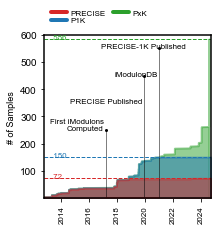

In [10]:
fig, ax = plt.subplots(figsize = (3,3))
ax.set_ylim(0,350)
ax.set_xlim(min(all_df.run_date), max(all_df.run_date))
plt.fill_between(all_df.run_date.values, all_df.cumulative_PxK.values, color = 'tab:green', alpha=0.5,lw=2)
plt.fill_between(all_df.run_date.values, all_df.cumulative_P1K.values, color = 'tab:blue', alpha=0.5,lw=2)
plt.fill_between(all_df.run_date.values, all_df.cumulative_P1.values, color = 'tab:red', alpha=0.5, lw=2)

ax.set_ylabel('# of Samples', fontsize=9)
ax.set_yticks([100, 200, 300, 400, 500, 600])
markerline, stemlines, baseline = ax.stem(
    [datetime(2017, 3, 1), datetime(2019, 12, 4), datetime(2021, 1, 8)], [250, 450, 550]
)
plt.setp(stemlines, 'linewidth', 0.5)
plt.setp(markerline, 'markersize', 2)
plt.setp(markerline, 'color', 'k')
plt.setp(stemlines, 'color', 'k')
ax.text(datetime(2017, 3, 1)-timedelta(50), 250, 'First iModulons\nComputed', ha='right', fontsize=8)
ax.text(datetime(2019, 12, 4)-timedelta(50), 350, 'PRECISE Published', ha='right', fontsize=8)
ax.text(datetime(2021, 1, 8)-timedelta(50), 450, 'iModulonDB', ha='right', fontsize=8)
ax.text(datetime(2023, 1, 8)-timedelta(50), 550, 'PRECISE-1K Published', ha='right', fontsize=8)
custom_lines = [Line2D([0], [0], color='tab:red', lw=4),
                Line2D([0], [0], color='tab:blue', lw=4),
                Line2D([0], [0], color='tab:green', lw=4)]
name = ['PRECISE', 'P1K', 'PxK']
args = {'handles':custom_lines,'labels':name,'loc':2,'ncol':2,
        'bbox_to_anchor':(0,1.2),'fontsize':8}
ax.legend(**args,  columnspacing=1, handletextpad=.4,
          frameon=False, labelspacing=0.11)

# need to update numbers
ax.axhline(y=(584), xmax=1, color ='tab:green', linestyle = '--', linewidth = 1)
ax.text(all_df.run_date.iloc[15],584,s=' 586', fontsize =8, color ='tab:green')
ax.axhline(y=(150), color ='tab:blue', linestyle = '--', linewidth = 1)
ax.text(all_df.run_date.iloc[15],150,s=' 150', fontsize =8, color ='tab:blue')
ax.axhline(y=(72), color ='tab:red', linestyle = '--', linewidth = 1)
ax.text(all_df.run_date.iloc[15],72,s=' 72', fontsize =8, color ='tab:red')

for s in ax.spines.values():
    s.set_color('black')
    s.set_linewidth(1.5)

ax.tick_params(axis='x', rotation=90, labelsize=8)

## Figure 1B

##### Carbon sources

In [11]:
# c_list = ica_data.sample_table['Carbon Source (g/L)'].value_counts().index.values
# c_list_short = [el.partition('(')[0] for el in c_list]
# np.unique(c_list_short)

In [12]:
# unique carbon source list
c_sources = ['acetate', 'glucose', 'Adenosine',
       'Cytidine', 'D-Alanine', 'D-Galactose', 'D-Galacturonic_acid',
       'D-Gluconic_acid', 'D-Glucosamine',
       'D-Glucose-6-Phosphate', 'D-Glucuronic_acid', 'D-Malic_acid',
       'D-Mannitol', 'D-Mannose', 'D-Melibiose', 'D-Saccharic_acid',
       'D-Serine', 'D-Trehalose', 'D-ribose',
       'DL-Malic_acid', 'Dulcitol',  'Inosine', 'L-Arabinose',
       'L-Asparagine', 'L-Aspartic_acid', 'L-Fucose', 'L-Lyxose',
       'L-Proline', 'L-Rhamnose', 'L-Serine', 'Maltose', 'Maltotriose',
       'Methylpyruvate', 'Mucic_acid',
       'N-Acetyl-Neuraminic_acid', 'N-acetylglucosamine',
       'Uridine', 'a-D-Lactose', 'a-Ketoglutaric_acid',
       'b-Methyl-D-Galactoside', 'fructose', 'glucarate', 'glycerol', 'm-Tartaric_acid', 'pyruvate']

len(c_sources)

45

##### Media

In [13]:
ica_data.sample_table['Base Media'].value_counts().index.values

array(['M9', 'CA-MHB', 'RPMI+10%LB', 'CAMHB', 'LB', 'DDB_BM_002', 'W2',
       'M9P buffer', 'TMA', '01xLB', 'TB', 'M9 gly', 'M9P'], dtype=object)

In [14]:
# unique media types after searching through publications and metadata

media_types = ['M9', 'CA-MHB', 'RPMI+10%LB', 'LB', 'DDB_BM_002', 'W2',
       'M9P buffer', 'TMA', '01xLB', 'TB']

len(media_types)

10

###### temperature

In [15]:
display(ica_data.sample_table['Temperature (C)'].value_counts().index.values)
len(ica_data.sample_table['Temperature (C)'].value_counts().index.values)

array([37, 30, 42], dtype=int64)

3

##### antibiotics

In [16]:
abx_list = ['Ciprofloxacin', 'Ampicillin', 'trimethoprim-sulfamethoxazole(16mg/mL)',
       'ceftriaxone(256ug/mL)', 'meropenem(128ug/mL)']

len(abx_list)

5

## Figure 1C
code for figure can be found in expression_QC_part2.ipynb

## Figure 1D

In [17]:
# logTPM values before normalization to project references
log_tpm = pd.read_csv('C:\\Users\\99hee\\precise_mg1655\\data\\QC\\log_tpm.csv').set_index('Geneid')
log_tpm.head()

,p1k_00001,p1k_00002,p1k_00003,p1k_00004,p1k_00005,p1k_00006,p1k_00011,p1k_00012,p1k_00019,p1k_00020,p1k_00027,p1k_00028,p1k_00029,p1k_00030,p1k_00031,p1k_00032,p1k_00041,p1k_00042,p1k_00050,p1k_00051,p1k_00052,p1k_00053,p1k_00054,p1k_00055,p1k_00064,p1k_00065,p1k_00071,p1k_00072,p1k_00073,p1k_00074,p1k_00082,p1k_00083,p1k_00084,p1k_00085,p1k_00094,p1k_00095,p1k_00106,p1k_00107,p1k_00161,p1k_00162,p1k_00163,p1k_00164,p1k_00165,p1k_00166,p1k_00167,p1k_00168,p1k_00169,p1k_00170,p1k_00171,p1k_00172,...,pxk_0434,pxk_0435,pxk_0436,pxk_0437,pxk_0440,pxk_0441,pxk_0442,pxk_0443,pxk_0444,pxk_0445,pxk_0446,pxk_0447,pxk_0448,pxk_0449,pxk_0450,pxk_0451,pxk_0452,pxk_0453,pxk_0454,pxk_0455,pxk_0456,pxk_0457,pxk_0458,pxk_0459,pxk_0460,pxk_0461,pxk_0462,pxk_0463,pxk_0464,pxk_0465,pxk_0466,pxk_0467,pxk_0470,pxk_0471,pxk_0472,pxk_0473,pxk_0476,pxk_0477,pxk_0478,pxk_0479,pxk_0480,pxk_0481,pxk_0482,pxk_0483,pxk_0484,pxk_0485,pxk_0486,pxk_0487,pxk_0488,pxk_0489
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
b0001,10.473122,10.271701,6.241820,6.612273,9.864203,10.306175,6.942872,7.396447,4.686936,4.969722,10.517558,10.398447,10.176092,10.063363,10.032638,10.305647,8.824708,8.088707,6.664473,6.833523,7.566344,6.600163,5.272057,5.574915,8.570109,7.021708,10.764091,10.438660,12.354989,11.172823,6.297226,5.678617,6.681065,7.074794,4.618168,4.297132,8.235738,9.230740,8.066901,8.406142,10.590453,10.074251,6.604377,7.427866,7.577329,7.532146,9.579314,10.711613,8.712772,8.721206,...,13.799642,14.220291,13.540423,14.661788,15.457679,16.140846,16.603621,16.021894,14.087060,14.004895,12.098326,14.221507,13.542974,13.879563,15.774674,16.566220,10.060566,10.983340,14.766780,15.058437,12.865020,13.220924,13.814342,14.026067,15.837487,16.320073,13.772381,13.265240,14.919695,14.884754,13.144341,12.960936,12.718851,12.997793,13.651072,14.584965,12.816557,13.202274,13.679881,14.171689,13.054429,14.430610,15.003129,13.993765,13.156986,13.543981,13.457623,12.783796,14.514099,14.777472
b0002,10.259970,10.368313,11.196750,11.408313,10.496462,10.234807,10.360030,10.371712,7.344004,7.353379,10.465959,10.508161,9.386969,9.347173,9.543012,9.582625,10.316950,10.738519,10.381412,10.319011,10.723661,10.699189,8.010324,7.880983,7.879539,7.762088,9.695135,9.730458,10.195272,10.577514,8.936148,8.957863,10.696140,10.450563,6.806713,6.835426,9.833025,9.781770,10.595673,10.579260,10.377098,10.087607,11.302940,11.147389,6.482345,6.443620,7.625530,7.721280,11.517317,11.556824,...,10.083670,9.914414,9.844946,10.030021,10.087339,9.867125,9.356643,9.620865,10.281878,10.270909,10.660176,10.164479,9.800176,9.961345,9.774157,9.195240,10.442144,10.140935,10.264050,10.290918,9.506977,9.706039,10.039598,10.058845,9.950561,9.771321,10.872851,10.489402,10.368457,10.071436,9.945564,9.954750,10.059900,10.147864,10.346214,10.335247,10.330446,10.246947,10.314501,9.796198,10.284493,10.100120,10.975759,10.958763,10.903817,10.906640,10.094332,10.380296,9.837189,9.785318
b0003,9.919679,10.043981,11.048725,11.464290,10.374269,10.216039,10.362168,10.420442,7.838860,7.874283,9.988891,10.094579,9.181923,9.052483,9.252464,9.295055,10.258286,10.538495,9.428845,9.723941,10.095103,10.086327,8.316095,8.392206,8.302738,8.189311,9.230988,9.455291,9.984595,10.298344,8.468001,8.425732,9.755760,9.866137,7.472919,7.709338,9.522414,9.530274,10.204698,10.210183,10.136117,9.749292,11.152623,10.899860,7.378036,7.342805,7.070834,7.135017,10.897575,10.913550,...,9.742833,9.729597,9.736111,9.820198,9.632170,9.173629,8.577414,9.151438,9.854620,9.776607,10.456935,10.063318,9.684729,9.783839,9.087324,8.791820,10.162052,9.809248,9.933327,9.966214,9.501341,9.556787,9.543564,9.562881,9.329245,9.083137,10.601805,10.267496,9.957433,9.822676,9.634675,9.557770,9.928297,10.084984,9.913276,9.705504,10.241886,10.186582,10.148453,9.534937,10.153224,9.897669,10.528434,10.608389,10.551635,10.575377,9.821258,10.091336,9.578890,9.492098
b0004,9.936095,10.010396,9.979940,10.334517,9.

In [18]:
# drop duplicate sample columns
log_tpm = log_tpm.drop(ica_data.sample_table.loc[ica_data.sample_table.project == 'CFP'].qc_id.values.tolist(), axis = 1)

In [19]:
# matching old column names (qc_id) to new column names
new_col = []
for col in log_tpm.columns:
    for idx in ica_data.sample_table.index.values:
        if ica_data.sample_table.loc[idx, 'qc_id'] == col:
            new_col.append(idx)
            
log_tpm.columns = new_col

In [20]:
pca = PCA()

log_tpm_z = pd.DataFrame(StandardScaler().fit_transform(log_tpm.T), index=log_tpm.T.index, columns=log_tpm.T.columns)

DF_weights = pd.DataFrame(pca.fit_transform(log_tpm_z), index=log_tpm_z.index)
DF_components = pd.DataFrame(pca.components_.T, index=log_tpm_z.columns)

Number of dimensions for 95% of variance: 180


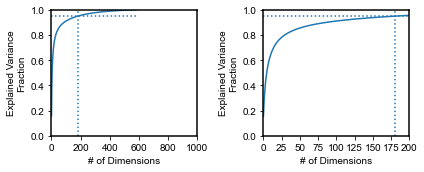

In [21]:
# Set the explained variance threshold
var_cutoff = 0.95

fig, (ax_all, ax_close) = plt.subplots(1, 2, figsize=(6,2.5))
pca_var = np.cumsum(pca.explained_variance_ratio_)
ax_all.plot(pca_var)
dims = np.where(pca_var > var_cutoff)[0][0] + 1
ax_all.vlines(dims,0,1,linestyles='dotted')
ax_all.hlines(var_cutoff,0,len(log_tpm.columns),linestyles='dotted')
ax_all.set_ylim(0,1)
ax_all.set_xlim(0,len(log_tpm.columns))
ax_all.set_ylabel('Explained Variance\nFraction',fontsize=10)
ax_all.set_xlabel('# of Dimensions',fontsize=10)
ax_all.set_xticks(np.arange(0, 1100, 200))
for s in ax_all.spines.values():
    s.set_color('black')
    s.set_linewidth(1.5)
    
ax_close.plot(pca_var)
dims = np.where(pca_var > var_cutoff)[0][0] + 1
ax_close.vlines(dims,0,1,linestyles='dotted')
ax_close.hlines(var_cutoff,0,len(log_tpm.columns),linestyles='dotted')
ax_close.set_ylim(0,1)
ax_close.set_xlim(0,150)
ax_close.set_ylabel('Explained Variance\nFraction',fontsize=10)
ax_close.set_xlabel('# of Dimensions',fontsize=10)
ax_close.set_xticks(np.arange(0, 225, 25))
for s in ax_close.spines.values():
    s.set_color('black')
    s.set_linewidth(1.5)
print(f'Number of dimensions for {var_cutoff*100:.0f}% of variance:', dims)
plt.tight_layout()

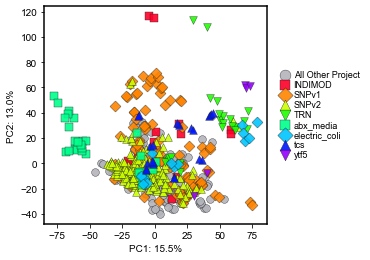

In [22]:
pmg_sample_table = ica_data.sample_table
# drop duplicate samples
pmg_sample_table = pmg_sample_table.drop(ica_data.sample_table.loc[ica_data.sample_table.project == 'CFP'].index.values)

show_study = []
study_sort = []
for exp_id in pmg_sample_table.index:
    if pmg_sample_table.loc[exp_id, 'project'] in ['INDIMOD', 'SNPv1', 'SNPv2','TRN', 'abx_media','electric_coli','tcs', 'ytf5']:
        show_study.append(pmg_sample_table.loc[exp_id, 'project'])
        study_sort.append(0)
    else:
        show_study.append('All Other Project')
        study_sort.append(1)
        
pmg_sample_table['show_study'] = show_study
pmg_sample_table['study_sort'] = study_sort
pmg_sample_table = pmg_sample_table.sort_values(by = ['study_sort', 'show_study'], ascending = [False,True])

NUM_COLORS = len(pmg_sample_table.groupby('show_study')) 
cm = pylab.get_cmap('gist_rainbow')
colors = ['#B4B4BB']+[cm(1.*i/(NUM_COLORS-1)) for i in range(0,NUM_COLORS-1)]
marker_list = ["o", "s", "D", "^", "v","s", "D", "^", "v", "s", "D", "^", "v","s", "D", "^", "v"]
plt.rc('xtick', labelsize=10)    # fontsize of the tick labels
plt.rc('ytick', labelsize=10)    # fontsize of the tick labels

fig,ax = plt.subplots(figsize=(4,4))

for s in ax.spines.values():
    s.set_color('black')
    s.set_linewidth(1.5)

for i,(name,group) in enumerate(pmg_sample_table.groupby('show_study', sort=False)):
    idx = log_tpm.loc[:,group.index.tolist()].columns.tolist()
    ax.scatter(DF_weights.loc[idx,0],
               DF_weights.loc[idx,1],
               label=name,alpha=0.9, color=colors[i],marker=marker_list[i], s=60, linewidths =0.4, edgecolors='#1C2021')
ax.set_xlabel('PC1: %.1f%%'%(pca.explained_variance_ratio_[0]*100),fontsize=10)
ax.set_ylabel('PC2: %.1f%%'%(pca.explained_variance_ratio_[1]*100),fontsize=10)
plt.legend(bbox_to_anchor=(1,0.5),loc='center left',fontsize=9,ncol=1, markerscale=1.4, columnspacing=0.2, handletextpad=.01,
          frameon=False, labelspacing=0.11)